# Part 1: Questions
1. What is Keras?

**Ans:**

Keras is a high-level deep learning API used to build, train, evaluate, save, and reuse neural network models. It works on top of TensorFlow and makes deep learning easier to implement

---

2. Why is Keras used instead of only NumPy?

**Ans:**

Keras is preferred because NumPy alone is not practical for deep learning. NumPy does not provide automatic differentiation, built-in neural network layers, optimizers, or an easy training pipeline.

---

3. What is a Fully Connected Neural Network?

**Ans:**

A Fully Connected Neural Network, also called a Dense Neural Network, is a neural network where each neuron in one layer is connected to every neuron in the next layer.

---
4. What is a Dense layer?

**Ans:**

A Dense layer is a fully connected layer in Keras. Each neuron receives input from all neurons of the previous layer and applies weights, bias, and an activation function.

---


# Task 0: Load Dataset from Google Drive

In [115]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [116]:
zip_file_path = "/content/drive/MyDrive/AI and Machine Learning/Week 4/Copy of devnagari digit.zip"
extract_path = "/content/"

!unzip -q "{zip_file_path}" -d "{extract_path}"

replace /content/DevanagariHandwrittenDigitDataset/Test/digit_0/103277.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: All


# Task 1: Data Preparation

In [117]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical

In [118]:
print(os.listdir("/content/"))

['.config', 'DevanagariHandwrittenDigitDataset', 'best_model.keras', 'devnagari_model.h5', 'drive', 'sample_data']


### Q2: Define dataset paths and image size

In [119]:
train_dir = "/content/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/DevanagariHandwrittenDigitDataset/Test/"
img_height, img_width = 28, 28

### Q3: Load images and labels from dataset

In [120]:
def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

### Q4: Load training and testing data

In [121]:
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

### Q5: Reshape images for Keras

In [122]:
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

### Q6: One-hot encode labels

In [123]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

### Q7: Check dataset shapes

In [124]:
print("Training set:", x_train.shape, y_train.shape)
print("Testing set:", x_test.shape, y_test.shape)

Training set: (17000, 28, 28, 1) (17000, 10)
Testing set: (3000, 28, 28, 1) (3000, 10)


### Q8: Display sample images

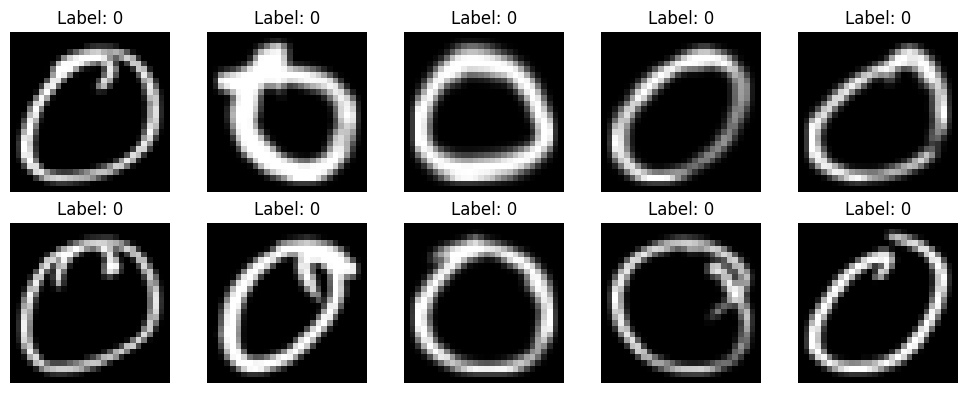

In [125]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Task 2: Build the FCN Model
### Qn9: Build the FCN Model

In [126]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])

### Q10: Display model summary

In [127]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Task 3: Compile the Model
### Q11: Compile model with optimizer, loss, metrics

In [128]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Task 4: Train the Model
### Q12: Train model using fit()

### Q13: Train with callbacks (optional better version)

In [129]:
callbacks = [
    keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4824 - loss: 1.6844 - val_accuracy: 0.8047 - val_loss: 0.7966
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8476 - loss: 0.5165 - val_accuracy: 0.9027 - val_loss: 0.3589
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9187 - loss: 0.2876 - val_accuracy: 0.9353 - val_loss: 0.2430
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9491 - loss: 0.1934 - val_accuracy: 0.9493 - val_loss: 0.1838
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9609 - loss: 0.1455 - val_accuracy: 0.9590 - val_loss: 0.1523
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9689 - loss: 0.1142 - val_accuracy: 0.9630 - val_loss: 0.1330
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9761 - loss: 0.0932 - val_accuracy: 0.9687 - val_loss: 0.1170
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9813 - loss: 0.0755 - val_accuracy: 0.

### Q14: Plot training and validation graphs

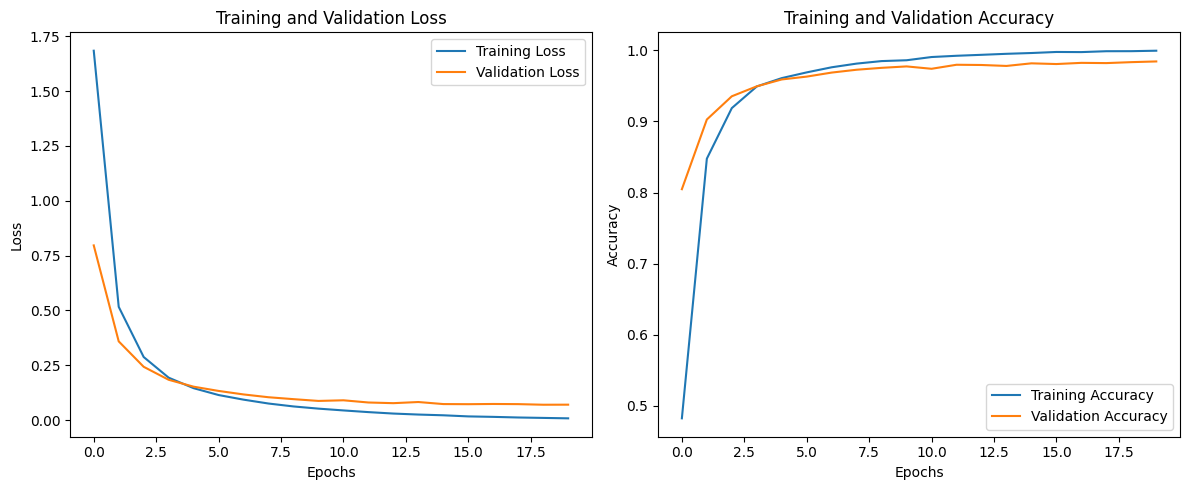

In [130]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# Task 5: Evaluate the Model

### Q15: Evaluate on test data

In [131]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

94/94 - 0s - 2ms/step - accuracy: 0.9833 - loss: 0.0700
Test Loss: 0.07002264261245728
Test Accuracy: 0.9833333492279053


# Task 6: Save and Load Model
### Q16: Save model

In [132]:
model.save("devnagari_model.h5")

### Q17: Load saved model

In [133]:
loaded_model = tf.keras.models.load_model("devnagari_model.h5")

### Q18: Evaluate loaded model

In [134]:
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test)

print("Loaded Model Accuracy:", loaded_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9833 - loss: 0.0700
Loaded Model Accuracy: 0.9833333492279053


# Task 7: Predictions
### Q19: Predict test images

In [135]:
predictions = model.predict(x_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


### Q20: Convert predictions to labels

In [136]:
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

### Q21: Print first prediction

In [137]:
print("Predicted:", predicted_labels[0])
print("Actual:", true_labels[0])

Predicted: 0
Actual: 0


### Q22: Display predicted images

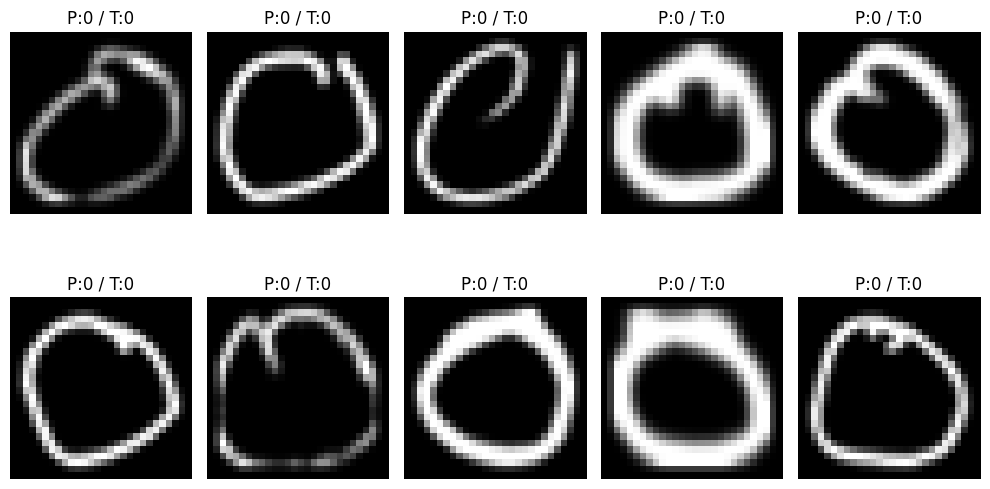

In [138]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"P:{predicted_labels[i]} / T:{true_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()